# House Price Prediction using Machine Learning


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("House_price_Dataset.csv")

In [6]:
df.head()

,Price,Area,Location,City,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,8686000,1511,Nallagandla Gachibowli,Hyderabad,2,0,0,1,1,1,...,1,0,1,0,0,0,0,0,0,0
1,12500000,1872,Om Nagar,Delhi,3,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
2,4695000,821,Gowrivakkam,Chennai,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3500000,675,Mansa Ram Park,Delhi,3,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,17000000,1050,Magathane,Mumbai,2,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0


## Understanding the dataset

In [7]:
df.shape

(7000, 41)

In [8]:
df.columns

Index(['Price', 'Area', 'Location', 'City', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator'],
      dtype='str')

In [9]:
df.dtypes

Price                  int64
Area                   int64
Location                 str
City                     str
No. of Bedrooms        int64
Resale                 int64
MaintenanceStaff       int64
Gymnasium              int64
SwimmingPool           int64
LandscapedGardens      int64
JoggingTrack           int64
RainWaterHarvesting    int64
IndoorGames            int64
ShoppingMall           int64
Intercom               int64
SportsFacility         int64
ATM                    int64
ClubHouse              int64
School                 int64
24X7Security           int64
PowerBackup            int64
CarParking             int64
StaffQuarter           int64
Cafeteria              int64
MultipurposeRoom       int64
Hospital               int64
WashingMachine         int64
Gasconnection          int64
AC                     int64
Wifi                   int64
Children'splayarea     int64
LiftAvailable          int64
BED                    int64
VaastuCompliant        int64
Microwave     

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Price                7000 non-null   int64
 1   Area                 7000 non-null   int64
 2   Location             7000 non-null   str  
 3   City                 7000 non-null   str  
 4   No. of Bedrooms      7000 non-null   int64
 5   Resale               7000 non-null   int64
 6   MaintenanceStaff     7000 non-null   int64
 7   Gymnasium            7000 non-null   int64
 8   SwimmingPool         7000 non-null   int64
 9   LandscapedGardens    7000 non-null   int64
 10  JoggingTrack         7000 non-null   int64
 11  RainWaterHarvesting  7000 non-null   int64
 12  IndoorGames          7000 non-null   int64
 13  ShoppingMall         7000 non-null   int64
 14  Intercom             7000 non-null   int64
 15  SportsFacility       7000 non-null   int64
 16  ATM                  7000 non-null 

In [11]:
df.describe()

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
count,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,...,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,7.966033e+06,1176.842857,2.403714,0.320571,0.046857,0.820857,0.164286,0.135143,0.139000,0.135429,...,0.891857,0.027000,0.111143,0.02000,0.007000,0.025714,0.023429,0.020857,0.003429,0.023857
std,3.658041e+06,361.347315,0.659604,0.466730,0.211348,0.383499,0.370561,0.341901,0.345971,0.342205,...,0.310583,0.162095,0.314331,0.14001,0.083379,0.158293,0.151271,0.142916,0.058458,0.152615
min,2.775000e+06,450.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.300000e+06,911.750000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000e+06,1140.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.517750e+06,1419.250000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.050000e+07,2615.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df['City'].value_counts()

City
Kolkata      1571
Bangalore    1500
Delhi        1261
Mumbai       1223
Chennai      1172
Hyderabad     273
Name: count, dtype: int64

# Missing Values

In [13]:
df.isnull().sum()

Price                  0
Area                   0
Location               0
City                   0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0


In [14]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


# Checking Duplicate Values


In [15]:
df.duplicated().sum()

np.int64(0)

# Save Clean Dataset

In [16]:
df.to_csv("House_Prediction_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Correlation

In [17]:
df.corr(numeric_only=True)

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
Price,1.000000,0.534624,0.212326,0.342588,0.187323,0.045583,0.123104,0.142184,0.131975,0.176711,...,0.043140,0.079461,0.130639,0.064750,0.053337,0.025523,0.021624,0.038455,0.051391,0.032566
Area,0.534624,1.000000,0.664611,-0.024463,0.093187,0.067288,0.275361,0.252031,0.247644,0.237153,...,0.009957,0.073455,0.180355,0.112055,0.024175,0.064345,0.068250,0.073502,0.016435,0.078029
No. of Bedrooms,0.212326,0.664611,1.000000,-0.102073,0.039543,-0.121293,0.086939,0.086218,0.073370,0.071071,...,-0.041419,0.022314,0.066093,0.048703,-0.009825,0.034664,0.029771,0.025854,-0.013670,0.036306
Resale,0.342588,-0.024463,-0.102073,1.000000,0.104074,-0.081423,-0.154200,-0.109468,-0.130880,-0.050008,...,0.031218,0.027218,-0.017924,-0.021602,-0.039314,-0.038104,-0.043658,-0.016715,0.074918,-0.035174
MaintenanceStaff,0.187323,0.093187,0.039543,0.104074,1.000000,-0.051546,0.268387,0.319672,0.264588,0.370565,...,-0.033802,0.167424,0.317324,0.069723,0.192191,0.057936,0.059507,0.062245,0.102639,0.053930
Gymnasium,0.045583,0.067288,-0.121293,-0.081423,-0.051546,1.000000,0.192046,0.122556,0.167243,0.066224,...,0.461097,-0.011818,0.002813,0.018840,0.039223,-0.044141,-0.021231,0.018652,-0.036331,-0.029497
SwimmingPool,0.123104,0.275361,0.086939,-0.154200,0.268387,0.192046,1.000000,0.751727,0.797005,0.669564,...,-0.062861,0.235370,0.547308,0.264373,0.189367,0.210523,0.244837,0.261733,0.072930,0.238910
LandscapedGardens,0.142184,0.252031,0.086218,-0.109468,0.319672,0.122556,0.751727,1.000000,0.721716,0.692265,...,-0.072250,0.184224,0.524950,0.209170,0.167290,0.165460,0.195689,0.211318,0.076895,0.187379
JoggingTrack,0.131975,0.247644,0.073370,-0.130880,0.264588,0.167243,0.797005,0.721716,1.000000,0.712291,...,-0.086133,0.144531,0.591033,0.184469,0.199057,0.146048,0.169819,0.178308,0.025884,0.164489
RainWaterHarvesting,0.176711,0.237153,0.071071,-0.050008,0.370565,0.066224,0.669564,0.692265,0.712291,1.000000,...,-0.039631,0.153011,0.645061,0.176062,0.132018,0.144076,0.159504,0.170108,0.069635,0.156988


# Exploratory Data Analysis

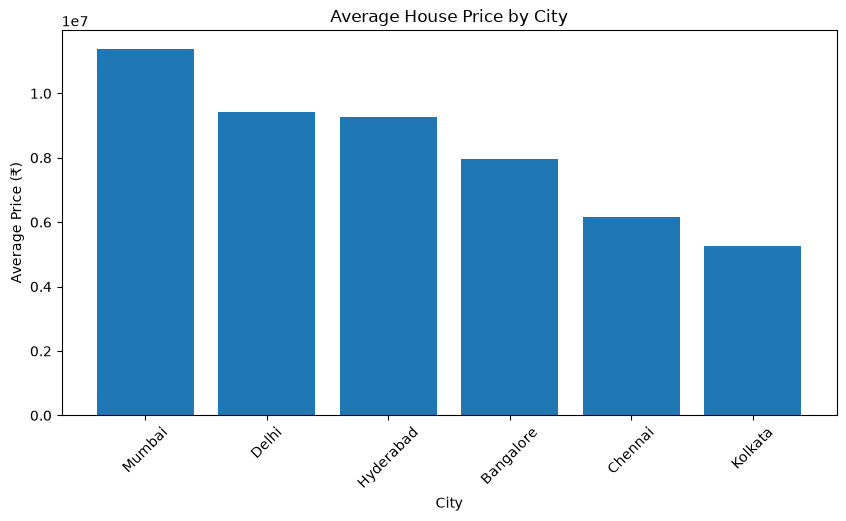

In [18]:
city_price = df.groupby("City")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(city_price.index, city_price.values)

plt.title("Average House Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

plt.show()

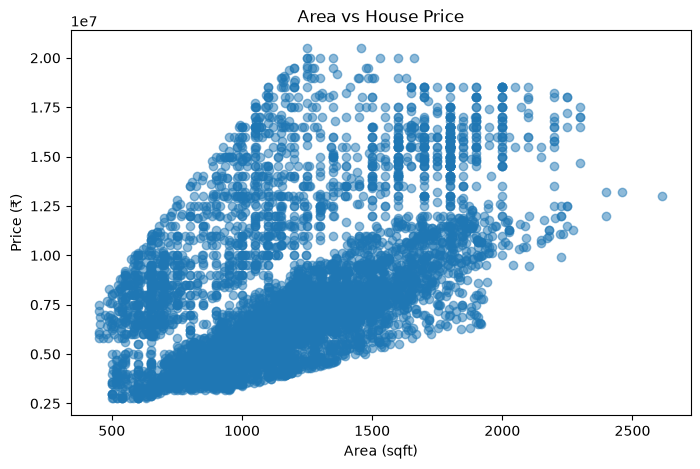

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["Price"],
    alpha=0.5
)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (₹)")

plt.show()

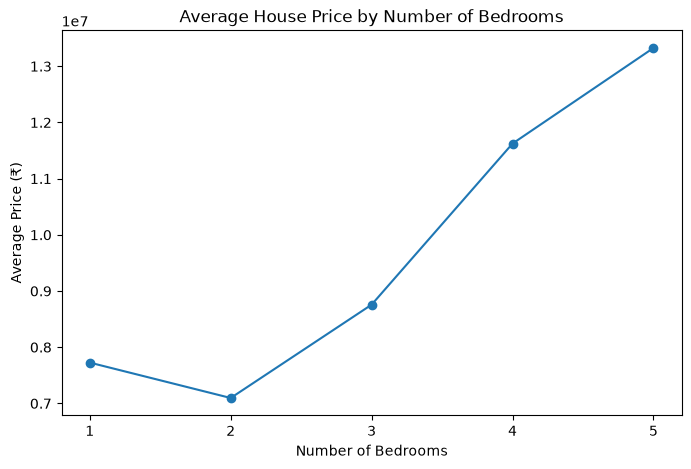

In [20]:
bedroom_price = df.groupby("No. of Bedrooms")["Price"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    bedroom_price.index,
    bedroom_price.values,
    marker="o"
)

plt.title("Average House Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price (₹)")

plt.xticks(bedroom_price.index)

plt.show()

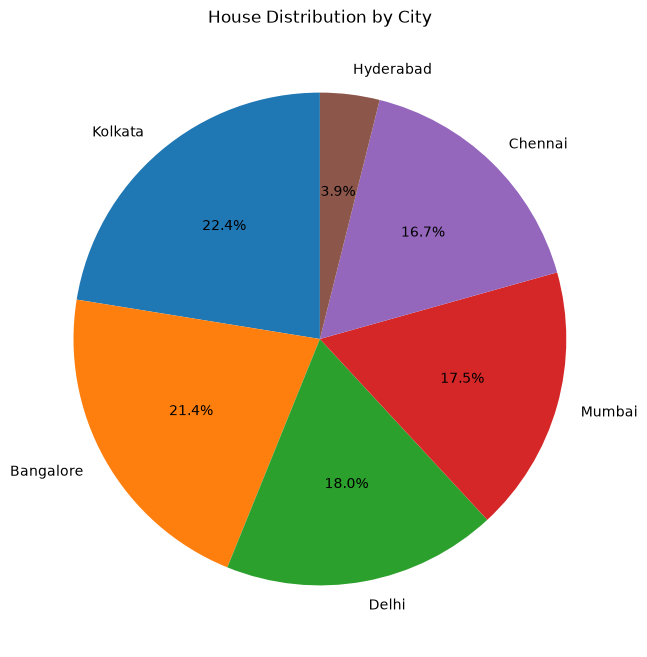

In [21]:
city_count = df["City"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    city_count.values,
    labels=city_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("House Distribution by City")

plt.show()

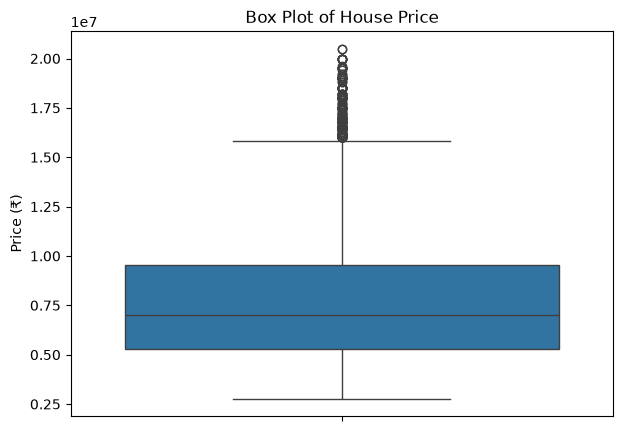

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(y=df["Price"])

plt.title("Box Plot of House Price")
plt.ylabel("Price (₹)")

plt.show()

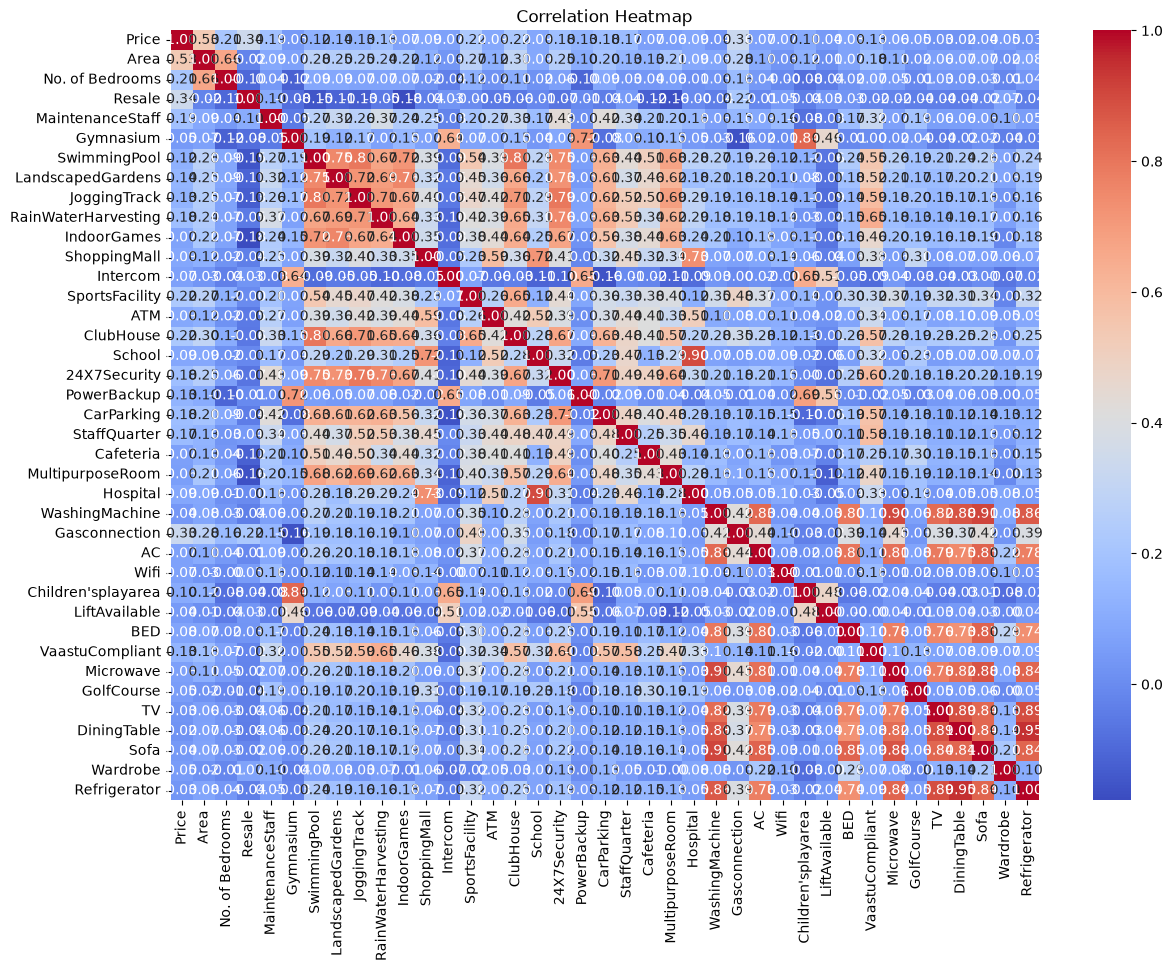

In [23]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Removing Outliers

In [24]:
Q1 = df["Area"].quantile(0.25)
Q3 = df["Area"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df["Area"] >= lower_limit) &
    (df["Area"] <= upper_limit)
]

print("Shape after Area outlier treatment:", df.shape)

Shape after Area outlier treatment: (6963, 41)


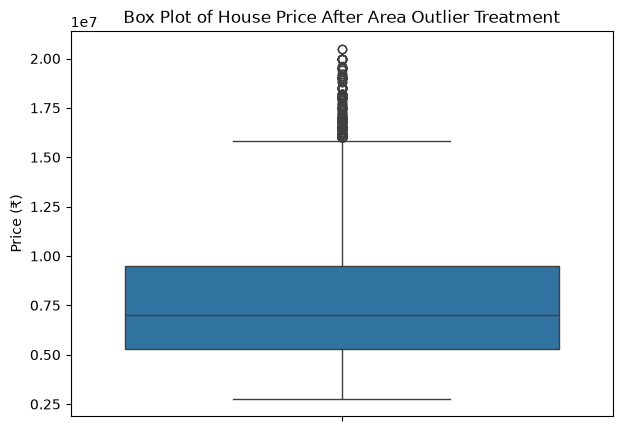

In [25]:
plt.figure(figsize=(7, 5))

sns.boxplot(y=df["Price"])

plt.title("Box Plot of House Price After Area Outlier Treatment")
plt.ylabel("Price (₹)")

plt.show()

## Feature Engineering

In [26]:
amenity_cols = [c for c in df.columns if df[c].dropna().isin([0,1]).all() and c not in ['Resale']]
df['Total_Amenities'] = df[amenity_cols].sum(axis=1)
df['Price_per_Sqft'] = df['Price'] / df['Area']
df['Bed_Area_Ratio'] = df['No. of Bedrooms'] / df['Area']
df[['Total_Amenities','Price_per_Sqft','Bed_Area_Ratio']].head()

,Total_Amenities,Price_per_Sqft,Bed_Area_Ratio
0,18,5748.510920,0.001324
1,5,6677.350427,0.001603
2,1,5718.635810,0.002436
3,2,5185.185185,0.004444
4,6,16190.476190,0.001905


## Check For Invalid House Prices

In [27]:
print("Invalid prices:", (df["Price"] <= 0).sum())

df = df[df["Price"] > 0]

Invalid prices: 0


## Separating Features and Target

In [28]:
X = df.drop(columns=["Price", "Price_per_Sqft"])
y = df["Price"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Area', 'Location', 'City', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'Total_Amenities',
       'Bed_Area_Ratio'],
      dtype='str')

Target:
Price


# Handling Categorical Data


In [29]:
print(X.dtypes)

Area                     int64
Location                   str
City                       str
No. of Bedrooms          int64
Resale                   int64
MaintenanceStaff         int64
Gymnasium                int64
SwimmingPool             int64
LandscapedGardens        int64
JoggingTrack             int64
RainWaterHarvesting      int64
IndoorGames              int64
ShoppingMall             int64
Intercom                 int64
SportsFacility           int64
ATM                      int64
ClubHouse                int64
School                   int64
24X7Security             int64
PowerBackup              int64
CarParking               int64
StaffQuarter             int64
Cafeteria                int64
MultipurposeRoom         int64
Hospital                 int64
WashingMachine           int64
Gasconnection            int64
AC                       int64
Wifi                     int64
Children'splayarea       int64
LiftAvailable            int64
BED                      int64
VaastuCo

In [30]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [31]:
X.head()

,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,IndoorGames,...,Location_mumbai,Location_nawada,Location_sarjapura attibele road,Location_south dum dum,Location_tambaram west,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,1511,2,0,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,0
1,1872,3,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,821,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,675,3,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1050,2,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [32]:
print("Shape after encoding:", X.shape)

Shape after encoding: (6963, 485)


## Train-Test-Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5570, 485)
X_test : (1393, 485)
y_train: (5570,)
y_test : (1393,)


# Linear Regression

### Create model

In [34]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

### Train the model

In [35]:
lr_model.fit(X_train, y_train)

print("Linear Regression Model trained successfully!")

Linear Regression Model trained successfully!


In [36]:
pd.options.display.float_format = '{:,.2f}'.format

### Prediction

In [37]:
lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:10])

[ 4383838.62866102  5954577.04545563 11546066.52924106  6492398.86399989
  5366516.67548852 10952164.6292884   6117812.59612718 16454205.44060417
  7739554.83042748  6250251.91977834]


In [38]:
lr_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": lr_predictions
})

lr_results.head(10)

,Actual Price,Predicted Price
0,3300000,"4,383,838.63"
1,5171000,"5,954,577.05"
2,8600000,"11,546,066.53"
3,6483000,"6,492,398.86"
4,4600000,"5,366,516.68"
5,12600000,"10,952,164.63"
6,5400000,"6,117,812.60"
7,16000000,"16,454,205.44"
8,6800000,"7,739,554.83"
9,7500000,"6,250,251.92"


### Model Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_mse = mean_squared_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)
print("R² Percentage:", lr_r2 * 100, "%")

Linear Regression Results
MAE : 1014457.3121600774
MSE : 2028203398654.6174
RMSE: 1424150.0618455266
R² Score: 0.8534220301392387
R² Percentage: 85.34220301392386 %


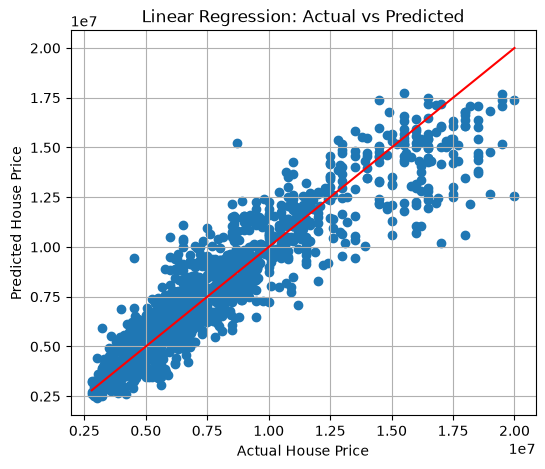

In [40]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    lr_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Decision Tree

### Create Model

In [41]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

### Train the model

In [42]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### Predict

In [43]:
dt_predictions = dt_model.predict(X_test)

### Evaluate

In [44]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)
print("R² Percentage:", dt_r2 * 100, "%")

Decision Tree Results
MAE : 1044089.7188322565
MSE : 2423973827198.583
RMSE: 1556911.631146284
R² Score: 0.8248197578102509
R² Percentage: 82.48197578102508 %


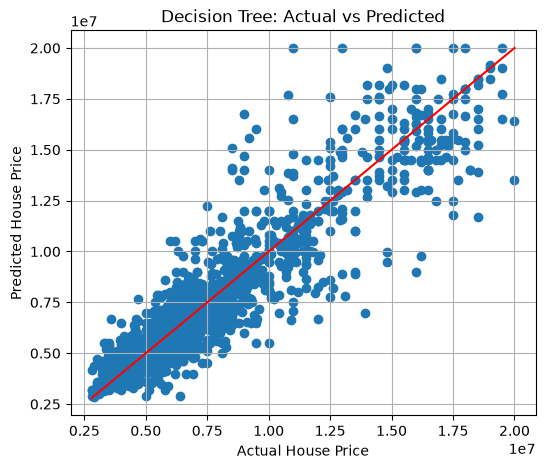

In [45]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    dt_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Random Forest

### Create Model

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

### Train the model

In [47]:
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Predict

In [48]:
rf_predictions = rf_model.predict(X_test)

### Evaluate

In [49]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)
print("R² Percentage:", rf_r2 * 100, "%")

Random Forest Results
MAE : 911884.1371421202
MSE : 1661583735154.1511
RMSE: 1289024.3345857172
R² Score: 0.8799175808431673
R² Percentage: 87.99175808431673 %


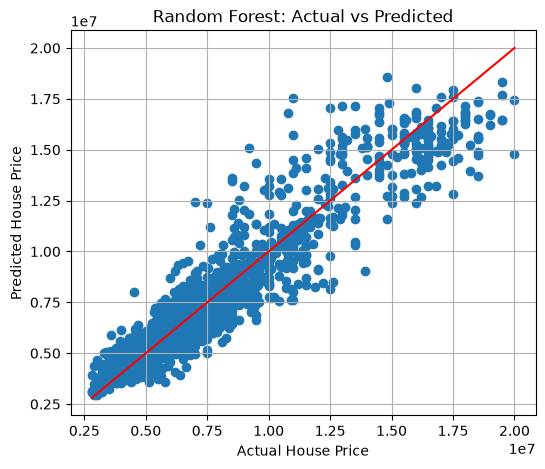

In [50]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

### Feature Importance

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,Area,0.46
484,City_Mumbai,0.29
481,City_Delhi,0.11
483,City_Kolkata,0.03
39,Bed_Area_Ratio,0.02
2,Resale,0.01
38,Total_Amenities,0.01
226,Location_Kharghar,0.01
27,Children'splayarea,0.00
281,Location_Mira Road East,0.00


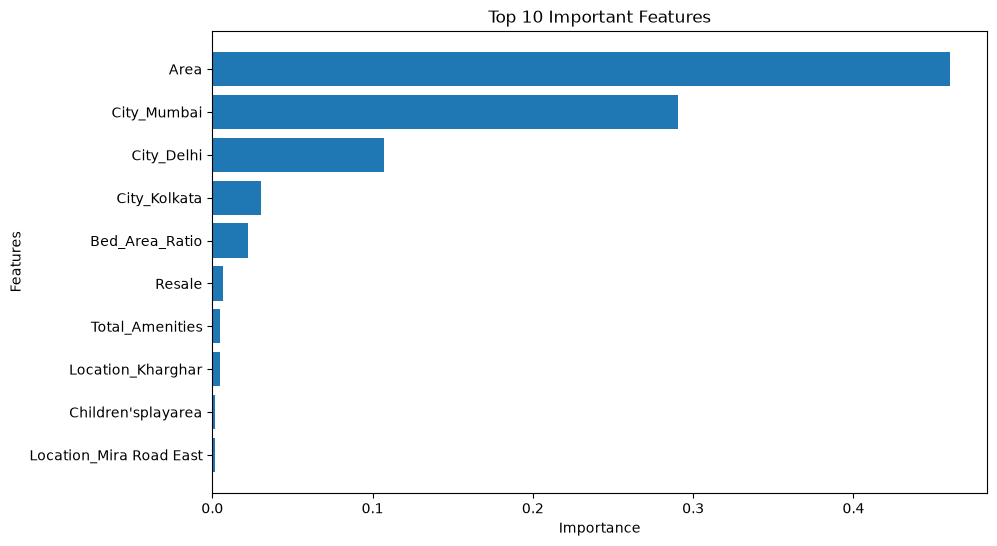

In [52]:
top10 = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# KNN

## Standard Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Create Model

In [54]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

### Train the model

In [55]:
knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### Predict

In [56]:
knn_predictions = knn_model.predict(
    X_test_scaled
)

### Evaluate

In [57]:
knn_mae = mean_absolute_error(
    y_test,
    knn_predictions
)

knn_mse = mean_squared_error(
    y_test,
    knn_predictions
)

knn_rmse = np.sqrt(knn_mse)

knn_r2 = r2_score(
    y_test,
    knn_predictions
)

print("KNN Results")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)
print("R² Percentage:", knn_r2 * 100, "%")

KNN Results
MAE : 1278955.0623115578
MSE : 3700535293804.847
RMSE: 1923677.5441338518
R² Score: 0.732562842995029
R² Percentage: 73.25628429950291 %


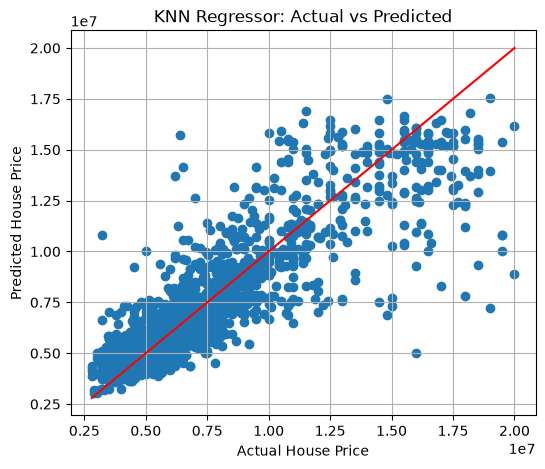

In [58]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    knn_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("KNN Regressor: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Support Vector Regressor

### Create Model

In [59]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf"
)

### Train The Model

In [60]:
svr_model.fit(
    X_train_scaled,
    y_train
)

print("SVR Model trained successfully!")

SVR Model trained successfully!


### Predict

In [61]:
svr_predictions = svr_model.predict(
    X_test_scaled
)

### Evaluate

In [62]:
svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_mse = mean_squared_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

print("SVR Results")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)
print("R² Percentage:", svr_r2 * 100, "%")

SVR Results
MAE : 2773943.23111824
MSE : 14848534017027.36
RMSE: 3853379.557872201
R² Score: -0.07310143206941566
R² Percentage: -7.310143206941566 %


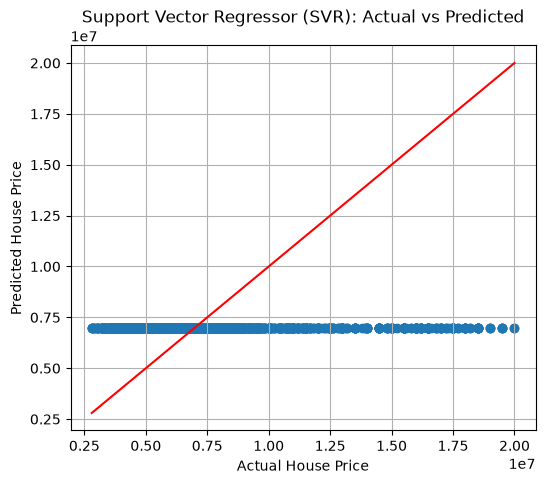

In [63]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    svr_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Support Vector Regressor (SVR): Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Comparison

In [64]:
comparison = pd.DataFrame({

    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],

    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        knn_mae,
        svr_mae
    ],

    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        knn_rmse,
        svr_rmse
    ],

    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        knn_r2,
        svr_r2
    ]
})

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

display(comparison)

,Algorithm,MAE,RMSE,R² Score
2,Random Forest,"911,884.14","1,289,024.33",0.88
0,Linear Regression,"1,014,457.31","1,424,150.06",0.85
1,Decision Tree,"1,044,089.72","1,556,911.63",0.82
3,KNN,"1,278,955.06","1,923,677.54",0.73
4,SVR,"2,773,943.23","3,853,379.56",-0.07


In [65]:
comparison_percentage = comparison.copy()

comparison_percentage["R² Percentage"] = (
    comparison_percentage["R² Score"] * 100
)

comparison_percentage

,Algorithm,MAE,RMSE,R² Score,R² Percentage
2,Random Forest,"911,884.14","1,289,024.33",0.88,87.99
0,Linear Regression,"1,014,457.31","1,424,150.06",0.85,85.34
1,Decision Tree,"1,044,089.72","1,556,911.63",0.82,82.48
3,KNN,"1,278,955.06","1,923,677.54",0.73,73.26
4,SVR,"2,773,943.23","3,853,379.56",-0.07,-7.31


# Best Model Selection

In [66]:
best_model_name = comparison.iloc[0]["Algorithm"]

print("Best Model:", best_model_name)
print("Best R² Score:", comparison.iloc[0]["R² Score"])
print(
    "Best R² Percentage:",
    comparison.iloc[0]["R² Score"] * 100,
    "%"
)

Best Model: Random Forest
Best R² Score: 0.8799175808431673
Best R² Percentage: 87.99175808431673 %


In [67]:
best_model = rf_model

print("Best Model: Random Forest")

Best Model: Random Forest


# Cross Validation

In [68]:
from sklearn.model_selection import cross_val_score

rf_cv_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_cv_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest Cross Validation R² Scores:")
print(rf_cv_scores)

print("\nMean Cross Validation R²:")
print(round(rf_cv_scores.mean(), 4))

print("\nMean Cross Validation R² Percentage:")
print(round(rf_cv_scores.mean() * 100, 2), "%")

print("\nStandard Deviation:")
print(round(rf_cv_scores.std(), 4))

Random Forest Cross Validation R² Scores:
[0.88752348 0.87480808 0.87970485 0.88341712 0.88030651]

Mean Cross Validation R²:
0.8812

Mean Cross Validation R² Percentage:
88.12 %

Standard Deviation:
0.0042


# Hyperparameter Tuning

## Random Forest Hyperparameter Tuning

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest Model
rf_model = RandomForestRegressor(random_state=42)

# Parameters to Test
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

# Randomized Search with 3-Fold Cross Validation
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=25,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train Randomized Search
random_search.fit(X_train, y_train)

# Display Best Parameters
print("Best Parameters")
print(random_search.best_params_)

# Display Best Cross Validation Score
print("\nBest Cross Validation Score")
print(round(random_search.best_score_, 4))

# Best Model
best_rf = random_search.best_estimator_

# Prediction using Tuned Model
opt_rf_prediction = best_rf.predict(X_test)

# Evaluation Metrics
opt_rf_mae = mean_absolute_error(y_test, opt_rf_prediction)
opt_rf_rmse = np.sqrt(mean_squared_error(y_test, opt_rf_prediction))
opt_rf_r2 = r2_score(y_test, opt_rf_prediction)

print("\nOptimized Random Forest Performance")
print(f"MAE      : {opt_rf_mae:,.2f}")
print(f"RMSE     : {opt_rf_rmse:,.2f}")
print(f"R² Score : {opt_rf_r2:.4f}")
print(f"R² Score % : {opt_rf_r2 * 100:.2f}%")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}

Best Cross Validation Score
0.8795

Optimized Random Forest Performance
MAE      : 949,823.39
RMSE     : 1,286,080.74
R² Score : 0.8805
R² Score % : 88.05%


## Comparison Table after model tuning

In [70]:
comparison_after_tuning = pd.DataFrame({
    "Algorithm": [
        "Linear Regression", "Decision Tree", "Random Forest",
        "Optimized Random Forest", "KNN", "SVR"
    ],
    "MAE": [lr_mae, dt_mae, rf_mae, opt_rf_mae, knn_mae, svr_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, opt_rf_rmse, knn_rmse, svr_rmse],
    "R² Score": [lr_r2, dt_r2, rf_r2, opt_rf_r2, knn_r2, svr_r2]
})

comparison_after_tuning = comparison_after_tuning.sort_values(
    by=["R² Score", "RMSE", "MAE"],
    ascending=[False, True, True]
).round(2)

display(comparison_after_tuning)

best_model_name = comparison_after_tuning.iloc[0]["Algorithm"]
print("\nBest Model:", best_model_name)

,Algorithm,MAE,RMSE,R² Score
3,Optimized Random Forest,"949,823.39","1,286,080.74",0.88
2,Random Forest,"911,884.14","1,289,024.33",0.88
0,Linear Regression,"1,014,457.31","1,424,150.06",0.85
1,Decision Tree,"1,044,089.72","1,556,911.63",0.82
4,KNN,"1,278,955.06","1,923,677.54",0.73
5,SVR,"2,773,943.23","3,853,379.56",-0.07



Best Model: Optimized Random Forest


# Select Best Model After Tuning

In [71]:
best_model = best_rf
print("Best Model: Optimized Random Forest")

Best Model: Optimized Random Forest


# Checking OverFitting

In [72]:
# Training Prediction
rf_train_prediction = best_model.predict(X_train)

# Testing Prediction
rf_test_prediction = best_model.predict(X_test)

# R² Scores
rf_train_r2 = r2_score(y_train, rf_train_prediction)
rf_test_r2 = r2_score(y_test, rf_test_prediction)

print("Overfitting Check")
print("-------------------------")
print(f"Training R² Score : {rf_train_r2:.4f}")
print(f"Testing R² Score  : {rf_test_r2:.4f}")
print(f"Difference        : {rf_train_r2 - rf_test_r2:.4f}")

if rf_train_r2 - rf_test_r2 > 0.10:
    print("Result: Model may be overfitting.")
else:
    print("Result: No significant overfitting.")

Overfitting Check
-------------------------
Training R² Score : 0.9267
Testing R² Score  : 0.8805
Difference        : 0.0462
Result: No significant overfitting.


## Save Best Model

In [73]:
import joblib

# Save model
joblib.dump(best_model, "Best_House_Price_Model.pkl")

# Save feature columns
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "model_columns.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


## Load The Model

In [74]:
loaded_model = joblib.load("Best_House_Price_Model.pkl")
loaded_columns = joblib.load("model_columns.pkl")

## Predict House Price for New Data

In [75]:
new_house = X_test.iloc[[10]]

predicted_price = loaded_model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))
print("Actual House Price: ₹{:,.2f}".format(y_test.iloc[10]))

Predicted House Price: ₹15,277,555.53
Actual House Price: ₹15,500,000.00


In [76]:
new_house = X_test.iloc[[5]]

predicted_price = loaded_model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))
print("Actual House Price: ₹{:,.2f}".format(y_test.iloc[5]))

Predicted House Price: ₹12,154,851.07
Actual House Price: ₹12,600,000.00
